In [ ]:
!nvidia-smi

Thu Jul  2 13:09:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Install

In [ ]:
!pip install -q supervision==0.23.0 ultralytics opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.5/151.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.6 MB/s eta 0:00:00


In [ ]:
!pip install --upgrade supervision==0.23.0

## Imports

In [ ]:
# prevent ultralytics from tracking your activity
!yolo settings sync=False

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Updated 'sync=False'
JSONDict("/root/.config/Ultralytics/settings.json"):
{
  "settings_version": "0.0.6",
  "datasets_dir": "/content/datasets",
  "weights_dir": "weights",
  "runs_dir": "runs",
  "uuid": "569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb",
  "sync": false,
  "api_key": "",
  "openai_api_key": "",
  "clearml": true,
  "comet": true,
  "dvc": true,
  "hub": true,
  "mlflow": true,
  "neptune": true,
  "raytune": true,
  "tensorboard": false,
  "wandb": false,
  "vscode_msg": true,
  "openvino_msg": true
}
💡 Learn more about Ultralytics Settings at https://docs.ultralytics.com/quickstart/#ultralytics-settings


In [ ]:
import cv2

import numpy as np
import supervision as sv

from tqdm import tqdm
from ultralytics import YOLO
from supervision.assets import VideoAssets, download_assets
from collections import defaultdict, deque
from typing import Tuple, Optional

## Download Data

**NOTE:** In this notebook we will use one of the Supervision Assets videos. [Here](https://supervision.roboflow.com/assets) you can learn more about it.

In [ ]:
download_assets(VideoAssets.VEHICLES)

  0%|          | 0/35345757 [00:00<?, ?it/s]

'vehicles.mp4'

## Configuration

In [ ]:
SOURCE_VIDEO_PATH = "vehicles.mp4"
TARGET_VIDEO_PATH = "vehicles-result.mp4"
CONFIDENCE_THRESHOLD = 0.3
IOU_THRESHOLD = 0.5
MODEL_NAME = "yolov8x.pt"
MODEL_RESOLUTION = 1280

# Real-world calibration: pixels to meters conversion
# This depends on your camera setup and perspective
PIXELS_PER_METER = 10.0  # Adjust based on your calibration

## Source and Target ROIs

![Source and Target ROIs](https://storage.googleapis.com/com-roboflow-marketing/notebooks/speed-estimation-perspective-1.png)

In [ ]:
SOURCE = np.array([
    [1252, 787],
    [2298, 803],
    [5039, 2159],
    [-550, 2159]
])

TARGET_WIDTH = 25
TARGET_HEIGHT = 250

TARGET = np.array([
    [0, 0],
    [TARGET_WIDTH - 1, 0],
    [TARGET_WIDTH - 1, TARGET_HEIGHT - 1],
    [0, TARGET_HEIGHT - 1],
])

In [ ]:
frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)
frame_iterator = iter(frame_generator)
frame = next(frame_iterator)

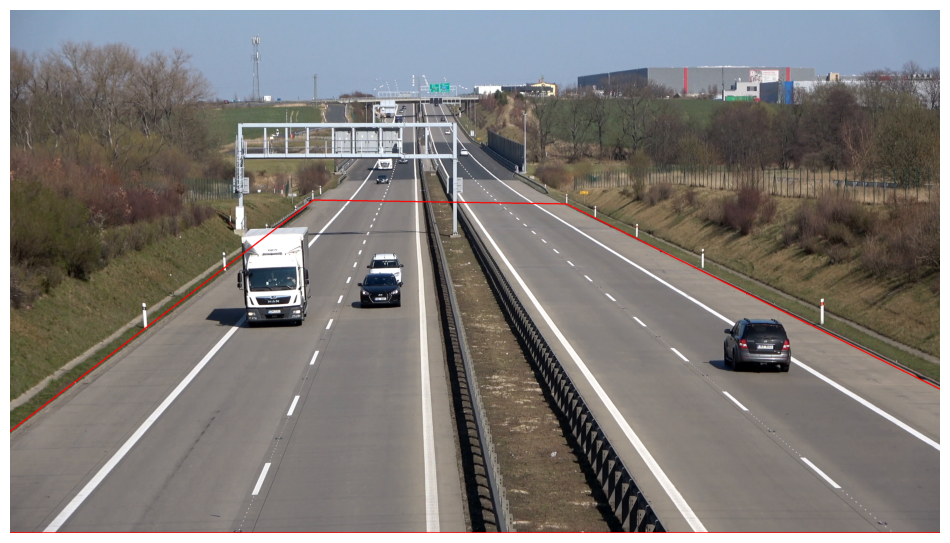

In [ ]:
annotated_frame = frame.copy()
# Draw polygon zone in red
annotated_frame = sv.draw_polygon(
    scene=annotated_frame,
    polygon=SOURCE,
    color=sv.Color.RED,
    thickness=4
)
sv.plot_image(annotated_frame)

## Transform Perspective

In [ ]:
class ViewTransformer:
    """
    A class to transform points from source perspective to bird's eye view.

    This uses perspective transformation to convert coordinates from the camera
    view to a top-down (bird's eye) view for accurate speed calculation.
    """

    def __init__(self, source: np.ndarray, target: np.ndarray) -> None:
        """
        Initialize the ViewTransformer.

        Args:
            source: Source polygon coordinates in camera view
            target: Target polygon coordinates in bird's eye view
        """
        source = source.astype(np.float32)
        target = target.astype(np.float32)
        self.m = cv2.getPerspectiveTransform(source, target)

    def transform_points(self, points: np.ndarray) -> np.ndarray:
        """
        Transform points from source to target perspective.

        Args:
            points: Array of points to transform

        Returns:
            Transformed points
        """
        if points.size == 0:
            return points

        reshaped_points = points.reshape(-1, 1, 2).astype(np.float32)
        transformed_points = cv2.perspectiveTransform(reshaped_points, self.m)
        return transformed_points.reshape(-1, 2)

In [ ]:
view_transformer = ViewTransformer(source=SOURCE, target=TARGET)

## Process Video

**NOTE:** In this tutorial we use Supervision Annotators. [Here](https://supervision.roboflow.com/annotators) you can learn more about it.

In [14]:
from collections import defaultdict, deque

from tqdm import tqdm

import supervision as sv

from ultralytics import YOLO



# Initialize YOLO model

model = YOLO(MODEL_NAME)



# Get video information and frame generator

video_info = sv.VideoInfo.from_video_path(video_path=SOURCE_VIDEO_PATH)

frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)



# 1. INITIALIZE TRACKER

byte_track = sv.ByteTrack(

    frame_rate=video_info.fps,

    track_activation_threshold=CONFIDENCE_THRESHOLD

)



# 2. CONFIGURE ANNOTATORS (using direct sv API for supervision 0.23.0)

bounding_box_annotator = sv.BoundingBoxAnnotator(

    thickness=2

)

label_annotator = sv.LabelAnnotator(

    text_scale=0.5,

    text_thickness=2,

    text_position=sv.Position.BOTTOM_CENTER

)

trace_annotator = sv.TraceAnnotator(

    thickness=2,

    trace_length=video_info.fps * 2,

    position=sv.Position.BOTTOM_CENTER

)



# Initialize Polygon zone

polygon_zone = sv.PolygonZone(

    polygon=SOURCE,

    frame_resolution_wh=video_info.resolution_wh

)



# Store trace coordinates for speed calculation

coordinates = defaultdict(lambda: deque(maxlen=video_info.fps))



# Open output video for writing

with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:



    # Loop through each frame of the video

    for frame in tqdm(frame_generator, total=video_info.total_frames):



        result = model(frame, imgsz=MODEL_RESOLUTION, verbose=False)[0]

        detections = sv.Detections.from_ultralytics(result)



        # Filter detections by confidence and remove class_id = 0 (person)

        detections = detections[detections.confidence > CONFIDENCE_THRESHOLD]

        detections = detections[detections.class_id != 0]



        # Filter detections within the polygon zone

        detections = detections[polygon_zone.trigger(detections)]



        # Remove overlapping boxes using Non-Maximum Suppression

        detections = detections.with_nms(IOU_THRESHOLD)



        # Update tracking IDs through ByteTrack

        detections = byte_track.update_with_detections(detections=detections)



        # Check if any tracker_id is returned to avoid empty errors

        if detections.tracker_id is not None and len(detections.tracker_id) > 0:



            # Get bottom center anchor coordinates of bounding boxes

            points = detections.get_anchors_coordinates(

                anchor=sv.Position.BOTTOM_CENTER

            )



            # Transform coordinates through ViewTransformer (Bird's eye view)

            points = view_transformer.transform_points(points=points).astype(int)



            # Store Y-axis coordinates for each ID to calculate speed

            for tracker_id, [_, y] in zip(detections.tracker_id, points):

                coordinates[tracker_id].append(y)



            # Format labels to display (ID and Speed)

            labels = []

            for tracker_id in detections.tracker_id:

                if len(coordinates[tracker_id]) < video_info.fps / 2:

                    labels.append(f"#{tracker_id}")

                else:

                    # Calculate speed based on Y-axis movement over time

                    coordinate_start = coordinates[tracker_id][-1]

                    coordinate_end = coordinates[tracker_id][0]

                    distance = abs(coordinate_start - coordinate_end)

                    time = len(coordinates[tracker_id]) / video_info.fps

                    speed = (distance / time) * 3.6  # Convert to km/h

                    labels.append(f"#{tracker_id} {int(speed)} km/h")

        else:

            labels = []



        # Draw annotations (Trace, Bounding Box, Labels) on frame

        annotated_frame = frame.copy()

        annotated_frame = trace_annotator.annotate(

            scene=annotated_frame, detections=detections

        )

        annotated_frame = bounding_box_annotator.annotate(

            scene=annotated_frame, detections=detections

        )

        annotated_frame = label_annotator.annotate(

            scene=annotated_frame, detections=detections, labels=labels

        )



        # Write annotated frame to output video

        sink.write_frame(annotated_frame)
# --- THÊM ĐOẠN ĐÂY VÀO NGOÀI KHỐI LỆNH WITH ---
print("Đang xử lý xong! Chuẩn bị tải video về máy...")

from google.colab import files
files.download(TARGET_VIDEO_PATH)

SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.
SupervisionWarnings: The `frame_resolution_wh` parameter is no longer required and will be dropped in version supervision-0.24.0. The mask resolution is now calculated automatically based on the polygon coordinates.
100%|██████████| 538/538 [02:08<00:00,  4.18it/s]

Đang xử lý xong! Chuẩn bị tải video về máy...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.